In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("customer_churn_business_dataset.csv")
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [3]:
df.dtypes

customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [5]:
df.avg_session_time.values

array([11.76237199, 26.84638961, 23.38006497, ..., 22.08987856,
       23.54948718, 14.79354865], shape=(10000,))

In [6]:
df.drop('complaint_type', axis='columns', inplace=True)
df.drop('customer_id', axis='columns', inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  10000 non-null  str    
 1   age                     10000 non-null  int64  
 2   country                 10000 non-null  str    
 3   city                    10000 non-null  str    
 4   customer_segment        10000 non-null  str    
 5   tenure_months           10000 non-null  int64  
 6   signup_channel          10000 non-null  str    
 7   contract_type           10000 non-null  str    
 8   monthly_logins          10000 non-null  int64  
 9   weekly_active_days      10000 non-null  int64  
 10  avg_session_time        10000 non-null  float64
 11  features_used           10000 non-null  int64  
 12  usage_growth_rate       10000 non-null  float64
 13  last_login_days_ago     10000 non-null  int64  
 14  monthly_fee             10000 non-null  int64  
 1

In [8]:
df[df.churn==1].tenure_months

1        9
16       4
36      40
48      11
61      35
        ..
9970    55
9983    58
9988    24
9990    25
9998    52
Name: tenure_months, Length: 1021, dtype: int64

In [9]:
tenure_churn_yes=df[df.churn==1].tenure_months
tenure_churn_no=df[df.churn==0].tenure_months

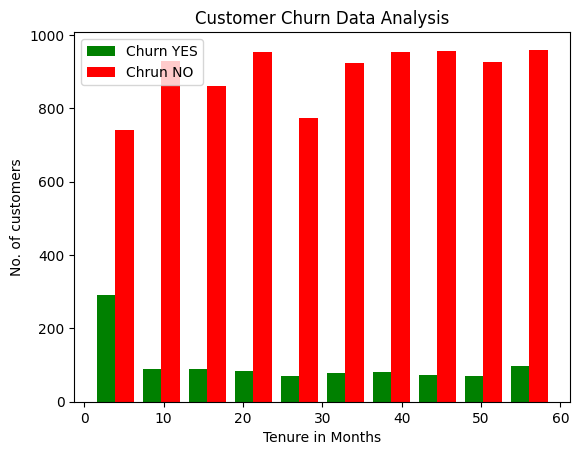

In [10]:
plt.hist([tenure_churn_yes,tenure_churn_no],color=['green','red'], label=['Churn YES','Chrun NO'])
plt.xlabel("Tenure in Months")
plt.ylabel("No. of customers")
plt.title("Customer Churn Data Analysis")
plt.legend()

In [11]:
usage_churn_yes=df[df.churn==1].avg_session_time
usage_churn_no=df[df.churn==0].avg_session_time

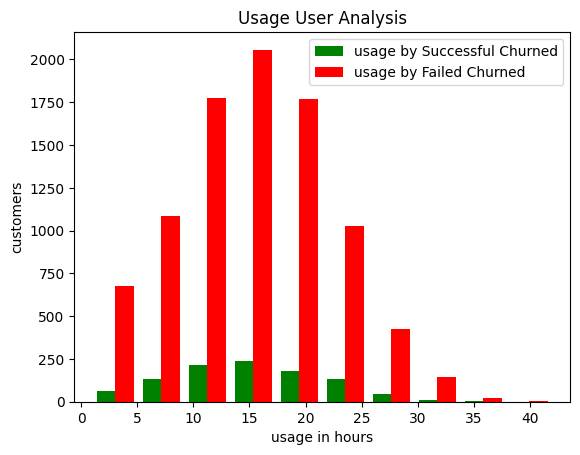

In [12]:
plt.hist([usage_churn_yes,usage_churn_no], color=['green', 'red'], label=['usage by Successful Churned', 'usage by Failed Churned'])
plt.title('Usage User Analysis')
plt.xlabel('usage in hours')
plt.ylabel('customers')
plt.legend()

In [13]:
def strchecker(df):
    for column in df:
        if df[column].dtype=='str':
            print(f'{column}: {df[column].unique()}')

In [14]:
def valchecker(df):
    for column in df:
        print(f'{df[column]}: {df[column].unique()}')

In [15]:
strchecker(df)

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
country: <StringArray>
['Bangladesh', 'Canada', 'Germany', 'Australia', 'India', 'USA', 'UK']
Length: 7, dtype: str
city: <StringArray>
['London', 'Sydney', 'New York', 'Dhaka', 'Delhi', 'Toronto', 'Berlin']
Length: 7, dtype: str
customer_segment: <StringArray>
['SME', 'Individual', 'Enterprise']
Length: 3, dtype: str
signup_channel: <StringArray>
['Web', 'Mobile', 'Referral']
Length: 3, dtype: str
contract_type: <StringArray>
['Monthly', 'Yearly', 'Quarterly']
Length: 3, dtype: str
payment_method: <StringArray>
['PayPal', 'Card', 'Bank Transfer']
Length: 3, dtype: str
discount_applied: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
price_increase_last_3m: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
survey_response: <StringArray>
['Satisfied', 'Neutral', 'Unsatisfied']
Length: 3, dtype: str


In [16]:
yes_no_col=['discount_applied', 'price_increase_last_3m']

for col in yes_no_col:
    df[col]=df[col].replace({'Yes':1,'No':0}).astype(int)

In [17]:
strchecker(df)

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
country: <StringArray>
['Bangladesh', 'Canada', 'Germany', 'Australia', 'India', 'USA', 'UK']
Length: 7, dtype: str
city: <StringArray>
['London', 'Sydney', 'New York', 'Dhaka', 'Delhi', 'Toronto', 'Berlin']
Length: 7, dtype: str
customer_segment: <StringArray>
['SME', 'Individual', 'Enterprise']
Length: 3, dtype: str
signup_channel: <StringArray>
['Web', 'Mobile', 'Referral']
Length: 3, dtype: str
contract_type: <StringArray>
['Monthly', 'Yearly', 'Quarterly']
Length: 3, dtype: str
payment_method: <StringArray>
['PayPal', 'Card', 'Bank Transfer']
Length: 3, dtype: str
survey_response: <StringArray>
['Satisfied', 'Neutral', 'Unsatisfied']
Length: 3, dtype: str


In [18]:
df=pd.get_dummies(data=df, columns=['gender','country','city','customer_segment','signup_channel','contract_type','payment_method','survey_response'],dtype=int)

In [19]:
df.dtypes

age                               int64
tenure_months                     int64
monthly_logins                    int64
weekly_active_days                int64
avg_session_time                float64
features_used                     int64
usage_growth_rate               float64
last_login_days_ago               int64
monthly_fee                       int64
total_revenue                     int64
payment_failures                  int64
discount_applied                  int64
price_increase_last_3m            int64
support_tickets                   int64
avg_resolution_time             float64
csat_score                      float64
escalations                       int64
email_open_rate                 float64
marketing_click_rate            float64
nps_score                         int64
referral_count                    int64
churn                             int64
gender_Female                     int64
gender_Male                       int64
country_Australia                 int64


In [20]:
valchecker(df)

0       68
1       57
2       24
3       49
4       65
        ..
9995    67
9996    26
9997    18
9998    30
9999    67
Name: age, Length: 10000, dtype: int64: [68 57 24 49 65 36 23 37 44 70 60 54 22 28 32 20 40 26 46 34 43 38 25 74
 55 59 41 52 72 31 27 29 61 63 51 58 48 18 56 21 30 39 35 19 53 71 67 47
 73 50 45 69 42 64 66 33 62]
0       22
1        9
2       58
3       19
4       52
        ..
9995    37
9996    42
9997    39
9998    52
9999     7
Name: tenure_months, Length: 10000, dtype: int64: [22  9 58 19 52 54  7 15 17 46 14 41 48  2  4  3 11  5 55 29 28 23 30 51
 43 12 27 59 40 49 47 44 38 16 32  1 35 36 21  8 26 57 13 24 53 50 20 33
 18 10 25 56 39  6 34 45 31 42 37]
0       26
1        7
2       19
3       34
4       20
        ..
9995    15
9996    13
9997    15
9998    14
9999    15
Name: monthly_logins, Length: 10000, dtype: int64: [26  7 19 34 20  1 21 17 29 18 31 24 28 32 14  9 22 23  3 27 33  0 15 10
  6 13  5 12 25  4 46 36 42 39 11 35 16  8 44 30 38 37 41 43  2 50 

In [21]:
num_cols = df.select_dtypes(include='number').columns

cols_to_scale = df[num_cols].columns[
    (df[num_cols].min() < 0) | (df[num_cols].max() > 1)
]

cols_to_scale

Index(['age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'nps_score', 'referral_count'],
      dtype='str')

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [23]:
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [24]:
valchecker(df)

0       0.892857
1       0.696429
2       0.107143
3       0.553571
4       0.839286
          ...   
9995    0.875000
9996    0.142857
9997    0.000000
9998    0.214286
9999    0.875000
Name: age, Length: 10000, dtype: float64: [0.89285714 0.69642857 0.10714286 0.55357143 0.83928571 0.32142857
 0.08928571 0.33928571 0.46428571 0.92857143 0.75       0.64285714
 0.07142857 0.17857143 0.25       0.03571429 0.39285714 0.14285714
 0.5        0.28571429 0.44642857 0.35714286 0.125      1.
 0.66071429 0.73214286 0.41071429 0.60714286 0.96428571 0.23214286
 0.16071429 0.19642857 0.76785714 0.80357143 0.58928571 0.71428571
 0.53571429 0.         0.67857143 0.05357143 0.21428571 0.375
 0.30357143 0.01785714 0.625      0.94642857 0.875      0.51785714
 0.98214286 0.57142857 0.48214286 0.91071429 0.42857143 0.82142857
 0.85714286 0.26785714 0.78571429]
0       0.362069
1       0.137931
2       0.982759
3       0.310345
4       0.879310
          ...   
9995    0.620690
9996    0.706897
9997    0.

Starting Machine Learning Process

In [25]:
x = df.drop('churn', axis='columns')
y = df['churn']

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=5)

In [27]:
x_train.shape

(8000, 52)

In [28]:
x_test.shape

(2000, 52)

In [29]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [30]:
scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [31]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, 
    max_depth=4,       
    learning_rate=0.05,
    early_stopping_rounds=50,
    scale_pos_weight=scale_weight,
    reg_lambda=10,     
    reg_alpha=1,       
    gamma=0.2,         
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr', 
    random_state=42
)

In [32]:
xgb_model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [33]:
from sklearn.metrics import f1_score

y_probs = xgb_model.predict_proba(x_test)[:, 1]
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.05):
    temp_pred = [1 if p > threshold else 0 for p in y_probs]
    score = f1_score(y_test, temp_pred)
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"Best Threshold: {best_threshold}")

Best Threshold: 0.5500000000000002


In [34]:
y_pred = [1 if p > best_threshold else 0 for p in y_probs]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.77      0.85      1787
           1       0.28      0.75      0.41       213

    accuracy                           0.77      2000
   macro avg       0.62      0.76      0.63      2000
weighted avg       0.89      0.77      0.81      2000



<Figure size 1000x1200 with 0 Axes>

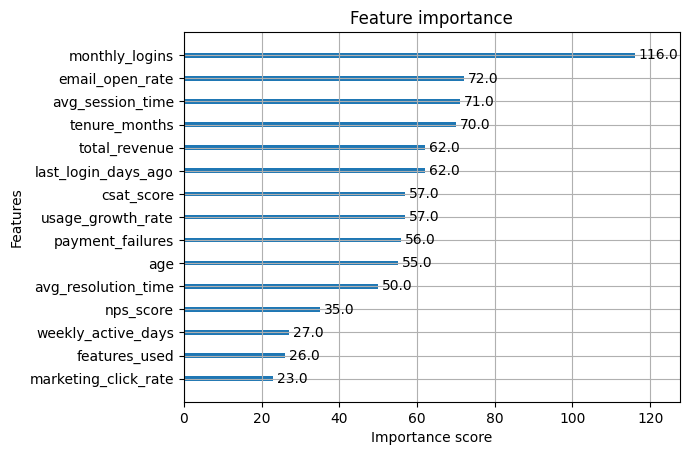

In [35]:
plt.figure(figsize=(10,12))
xgb.plot_importance(xgb_model, max_num_features=15)
plt.show()

For Deployment and backend purposes

In [ ]:
# import joblib

# joblib.dump(xgb_model, "model.pkl")
# joblib.dump(best_threshold, "threshold.pkl")
# joblib.dump(x_train.columns, "feature_names.pkl")

['feature_names.pkl']

Creating baseline in-order to enable few features What-if prediction.

In [ ]:
# baseline = x_train.mean()
# import joblib
# joblib.dump(baseline, "baseline.pkl")

['baseline.pkl']

Creating scalar to convert the inputs before using them for predictions :)

In [ ]:
# joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']